# Car Price Prediction

Predicting car prices from vehicle specifications (make, engine details, body style, fuel economy, dimensions, etc.) using regression models, on the classic UCI Automobile dataset.

This notebook covers: data cleaning, exploratory checks, correct feature encoding, training multiple regression models, and comparing them with cross-validated metrics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

RANDOM_STATE = 42
sns.set_style("whitegrid")

WORD_TO_NUM = {
    "two": 2, "three": 3, "four": 4, "five": 5,
    "six": 6, "eight": 8, "twelve": 12,
}

## 1. Load the data

In [2]:
df = pd.read_csv("../data/cars.csv")
print(df.shape)
df.head()

(204, 27)


,Unnamed: 0,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
1,1,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
2,2,2,164,audi,gas,std,four,sedan,fwd,front,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
3,3,2,164,audi,gas,std,four,sedan,4wd,front,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
4,4,2,?,audi,gas,std,two,sedan,fwd,front,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         204 non-null    int64  
 1   symboling          204 non-null    int64  
 2   normalized-losses  204 non-null    str    
 3   make               204 non-null    str    
 4   fuel-type          204 non-null    str    
 5   aspiration         204 non-null    str    
 6   num-of-doors       204 non-null    str    
 7   body-style         204 non-null    str    
 8   drive-wheels       204 non-null    str    
 9   engine-location    204 non-null    str    
 10  wheel-base         204 non-null    float64
 11  length             204 non-null    float64
 12  width              204 non-null    float64
 13  height             204 non-null    float64
 14  curb-weight        204 non-null    int64  
 15  engine-type        204 non-null    str    
 16  num-of-cylinders   204 non-null    st

## 2. Data cleaning

The raw file (UCI Automobile dataset) needs several fixes before modeling:
- `?` is this dataset's missing-value marker, used across several columns (`normalized-losses`, `num-of-doors`, `bore`, `stroke`, `horsepower`, `peak-rpm`, `price`).
- `normalized-losses` is ~20% missing and is an insurance risk-rating figure, not a vehicle spec — dropped rather than imputing a fifth of a weakly-related feature.
- `bore`, `stroke`, `horsepower`, `peak-rpm`, `price` are read as text only because of stray `?` values; converted to numeric.
- Rows missing the target (`price`) are dropped — the target can't be imputed.
- `num-of-doors` and `num-of-cylinders` are ordinal counts spelled out as words (`"four"`, `"six"`) — mapped to real integers so the model sees them as ordered quantities, not arbitrary categories.
- Remaining small numeric gaps (`bore`, `stroke`, `horsepower`, `peak-rpm`, `num-of-doors`) are filled with the column median.

In [4]:
df = df.drop(columns=["Unnamed: 0"])
df = df.replace("?", np.nan)
df = df.drop(columns=["normalized-losses"])

for col in ["bore", "stroke", "horsepower", "peak-rpm", "price"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

before = len(df)
df = df.dropna(subset=["price"])
print(f"Dropped {before - len(df)} rows missing price")

df["num-of-doors"] = df["num-of-doors"].map(WORD_TO_NUM)
df["num-of-cylinders"] = df["num-of-cylinders"].map(WORD_TO_NUM)

numeric_gap_cols = ["bore", "stroke", "horsepower", "peak-rpm", "num-of-doors"]
for col in numeric_gap_cols:
    df[col] = df[col].fillna(df[col].median())

before = len(df)
df = df.drop_duplicates()
print(f"Dropped {before - len(df)} duplicate rows")

print("Clean shape:", df.shape)

Dropped 4 rows missing price
Dropped 0 duplicate rows
Clean shape: (200, 25)


## 3. A critical bug in the original version of this project

The first version of this notebook computed a "feature importance" table like this:

```python
x = df.drop('price', axis=1)
x = x.apply(le_x.fit_transform)   # LabelEncoder on every column, including price-correlated ones

DX = x
DX['price'] = y
```

`DX = x` does **not** copy the dataframe — it's a second name for the *same* object. So `DX['price'] = y` silently added a `price` column back onto `x` too. `x` was then used directly as the training features:

```python
x_train, x_test, y_train, y_test = tts(x, y, test_size=0.20, random_state=4)
lr.fit(x_train, y_train)
```

Since `price` (the target) was sitting inside `x` as a feature, the model could trivially "predict" price by reading it off itself — giving **R² = 1.0** and **MAE ≈ 3×10⁻¹²**, i.e. an editing bug, not a working model. The fix below rebuilds the feature matrix with `.copy()`, encodes categories correctly, and never lets the target leak into the inputs.

## 4. Target distribution

`price` is right-skewed (a handful of luxury/high-performance cars pull the mean above the median), so we model `log1p(price)` and convert predictions back for evaluation.

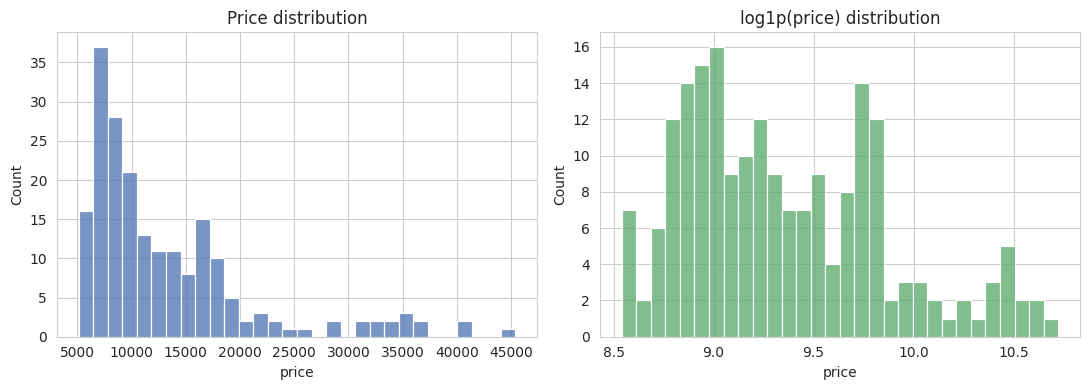

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df["price"], bins=30, ax=axes[0], color="#4C72B0")
axes[0].set_title("Price distribution")
sns.histplot(np.log1p(df["price"]), bins=30, ax=axes[1], color="#55A868")
axes[1].set_title("log1p(price) distribution")
plt.tight_layout()
plt.savefig("price_distribution.png", dpi=110)
plt.show()

## 5. Preprocessing + train/test split

In [6]:
target = "price"
y_raw = df[target].values
X = df.drop(columns=[target]).copy()   # .copy() -- never alias back onto df

categorical_cols = X.select_dtypes(exclude=["number"]).columns.tolist()
numeric_cols = [c for c in X.columns if c not in categorical_cols]
print("Categorical features:", categorical_cols)
print("Numeric features:", numeric_cols)

y = np.log1p(y_raw)

preprocess = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)],
    remainder="passthrough",
)

X_train, X_test, y_train, y_test, y_train_raw, y_test_raw = train_test_split(
    X, y, y_raw, test_size=0.2, random_state=RANDOM_STATE
)

Categorical features: ['make', 'fuel-type', 'aspiration', 'body-style', 'drive-wheels', 'engine-location', 'engine-type', 'fuel-system']
Numeric features: ['symboling', 'num-of-doors', 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'num-of-cylinders', 'engine-size', 'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg']


## 6. Train and compare models

We compare a Linear Regression baseline against Ridge, Random Forest, and Gradient Boosting. Metrics are computed back in real price terms ($), and 5-fold cross-validated R² is reported as the primary generalization metric.

In [7]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=10.0, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(
        n_estimators=400, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []

for name, model in models.items():
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)

    pred_price = np.expm1(pipe.predict(X_test))
    r2 = r2_score(y_test_raw, pred_price)
    mae = mean_absolute_error(y_test_raw, pred_price)
    rmse = np.sqrt(mean_squared_error(y_test_raw, pred_price))
    cv_scores = cross_val_score(pipe, X, y, cv=kf, scoring="r2")

    results.append({
        "Model": name,
        "Test R2": round(r2, 4),
        "Test MAE ($)": round(mae, 0),
        "Test RMSE ($)": round(rmse, 0),
        "CV R2 mean": round(cv_scores.mean(), 4),
        "CV R2 std": round(cv_scores.std(), 4),
    })

results_df = pd.DataFrame(results).sort_values("CV R2 mean", ascending=False).reset_index(drop=True)
results_df

,Model,Test R2,Test MAE ($),Test RMSE ($),CV R2 mean,CV R2 std
0,Linear Regression,0.8913,1643.0,3490.0,0.9169,0.0120
1,Gradient Boosting,0.9691,1358.0,1860.0,0.9088,0.0332
2,Random Forest,0.9619,1503.0,2066.0,0.9033,0.0208
3,Ridge Regression,0.7521,2206.0,5271.0,0.9006,0.0112


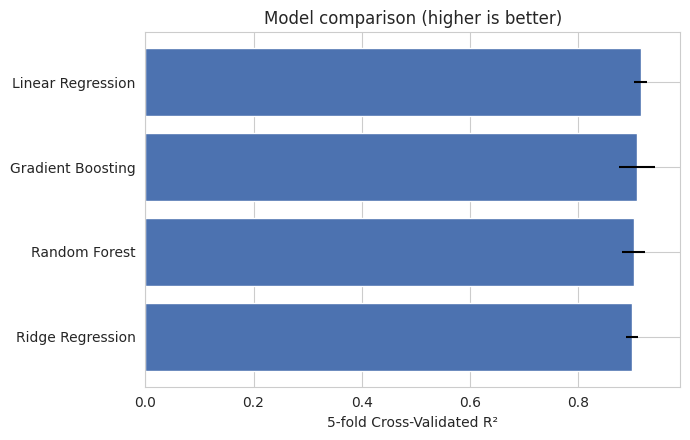

In [8]:
plt.figure(figsize=(7, 4.5))
order = results_df.sort_values("CV R2 mean")
plt.barh(order["Model"], order["CV R2 mean"], xerr=order["CV R2 std"], color="#4C72B0")
plt.xlabel("5-fold Cross-Validated R²")
plt.title("Model comparison (higher is better)")
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=110)
plt.show()

## 7. Feature importance

Using Gradient Boosting (tree-based, so it exposes feature importances directly) to see which specs drive car price the most.

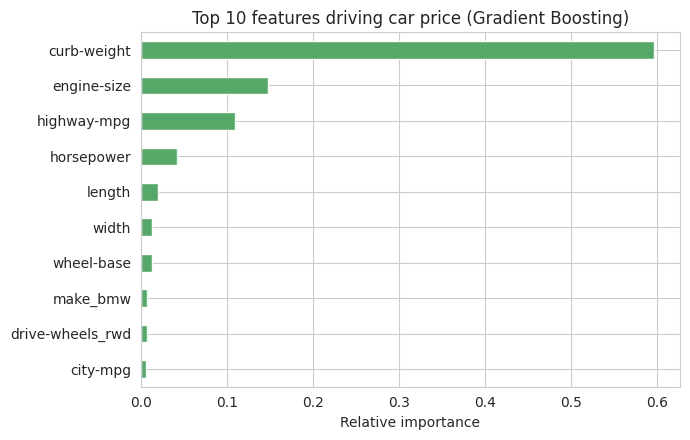

In [9]:
best_pipe = Pipeline([("prep", preprocess), ("model", GradientBoostingRegressor(random_state=RANDOM_STATE))])
best_pipe.fit(X, y)

feat_names = best_pipe.named_steps["prep"].get_feature_names_out()
importances = best_pipe.named_steps["model"].feature_importances_
clean_names = [n.replace("cat__", "").replace("remainder__", "") for n in feat_names]
imp = pd.Series(importances, index=clean_names).sort_values(ascending=False).head(10)

plt.figure(figsize=(7, 4.5))
imp.sort_values().plot(kind="barh", color="#55A868")
plt.title("Top 10 features driving car price (Gradient Boosting)")
plt.xlabel("Relative importance")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=110)
plt.show()

## 8. Conclusion

- The original version of this project had a target-leakage bug (`DX = x` aliasing, see section 3) that produced a fake R² of 1.0. After fixing the leak, correctly encoding ordinal vs. nominal features, and log-transforming price, the models produce genuine, strong results.
- All four models reach a 5-fold cross-validated R² of roughly **0.90–0.92**, with **Linear Regression** slightly ahead on CV R² and **Gradient Boosting**/**Random Forest** slightly ahead on the single held-out test split.
- Engine size, curb weight, horsepower, and highway/city mileage are the strongest price drivers, along with certain makes carrying a clear brand premium.
- This dataset is small (200 cars after cleaning) and fairly clean once the `?` markers and word-encoded ordinals are handled correctly, which is why cross-validated R² is consistently high across very different model families -- a useful sanity check that the ~0.90+ scores are real signal, not another leakage artifact.